# Score-Based Generative Models

There is a lot of mathematical machinery that was used to inspire score based models and diffusion models, and it is a bit confusing:

To summarize:
- Diffusion models: physical diffusion inspired discrete Markov chain, also hierarchical variational autoencoders
- Score-based Models: Stochastic Gradient Langevin Dynamics sampling with score matching
- Common framework: Continuous Stochastic differential equations: discretize to obtain both algorithms as reparametrisations from each other.

Here we look at the Stochastic Gradient Langevin Dynamics based approach.

## Starting Point

**Goal**: Sample from a data distribution $p_\text{data}(x)$ which is known from examples (data points, images).

**Idea**: Learn the **score function** $\mathbf{s}(\mathbf{x}) = \nabla_{\mathbf{x}}\log p(\mathbf{x})$ — the gradient of the log-density, a vector field pointing toward high-probability regions. With the score, we can sample from $p_\text{data}$ by noisy gradient ascent (!)


## Sampling with the Score — Stochastic Gradient Langevin Dynamics (SGLD)

Given $\mathbf{s}(\mathbf{x})$ we can produce samples distributed as $p(\mathbf{x})$ with the SGLD update (after many steps with small $\delta$)

$$\mathbf{x}_{t+1} = \mathbf{x}_t + \delta\,\mathbf{s}(\mathbf{x}_t) + \sqrt{2\delta}\,\varepsilon_t, \qquad \varepsilon_t\sim\mathcal{N}(\mathbf{0},\mathbf{I})$$

starting from an initial $\mathbf{x}_0$ (e.g. Gaussian noise).

A nice property of the score: it works for unnormalised density $\tilde{p}(\mathbf{x})$. If $p(\mathbf{x}) = \tilde{p}(\mathbf{x})/Z$ with $Z = \int \tilde{p}(\mathbf{x})\,d\mathbf{x}$, then
$\mathbf{s}(\mathbf{x}) = \nabla_{\mathbf{x}}\log p(\mathbf{x}) = \nabla_{\mathbf{x}}\log\tilde{p}(\mathbf{x})$, because $Z$ is just a constant.

## Learning (matching) the Score

We don't know $p$; we have samples.
**Main trick:** use the score of a noisy version of $p$ (convolved with a gaussian).

Then the score is the noise! $\tilde{\mathbf{x}} = \mathbf{x} + \sigma\varepsilon$ for $\varepsilon\sim\mathcal{N}(\mathbf{0},\mathbf{I})$:

$$s(\tilde x) = -\frac{\varepsilon}{\sigma}$$

**Objective**:
$$\mathcal{L}_{\text{DSM}}(\sigma) = \mathbb{E}_{\mathbf{x}\sim p_\text{data},\,\varepsilon\sim\mathcal{N}}\!\left[\left\|\mathbf{s}_\theta(\mathbf{x}+\sigma\varepsilon,\,\sigma) + \frac{\varepsilon}{\sigma}\right\|^2\right]$$

**An empirical trick**: to make the sampling generate both sharp and diverse samples start diffusion with large noise and reduce it. For that:
Train a noise-conditional network $\mathbf{s}_\theta(\tilde{\mathbf{x}},\sigma)$ across a geometric sequence of noise levels $\sigma_1 < \sigma_2 < \cdots < \sigma_L$ (fine → coarse), with the weighted loss

$$\mathcal{L}_{\text{NCSN}} = \frac{1}{L}\sum_{i=1}^{L}\sigma_i^2\cdot\mathcal{L}_{\text{DSM}}(\sigma_i)$$

## Training
- **Input:** a noisy sample $\tilde{\mathbf{x}} = \mathbf{x} + \sigma\varepsilon$ and the noise level $\sigma$ (or $\log\sigma$), with $\mathbf{x}\sim p_\text{data}$ and $\varepsilon\sim\mathcal{N}(\mathbf{0},\mathbf{I})$.
- **Target:** the score $\mathbf{s}_\theta(\tilde{\mathbf{x}},\sigma)=\varepsilon/\sigma$.
- **Loss:** $\sigma^2\,\|\mathbf{s}_\theta(\tilde{\mathbf{x}},\sigma) + \varepsilon/\sigma\|^2$, averaged over random $\sigma$ and a batch of data points.

## Sampling
1. Initial sample: $\mathbf{x}_0$ from a broad distribution $\mathcal{N}(\mathbf{0},\sigma_L^2\mathbf{I})$.
2. **Update step at scale $\sigma_i$**
$$\mathbf{x}_{t+1} = \mathbf{x}_t + \delta_i\,\mathbf{s}_\theta(\mathbf{x}_t,\sigma_i) + \sqrt{2\delta_i}\,\varepsilon_t,\qquad \varepsilon_t\sim\mathcal{N}(\mathbf{0},\mathbf{I})$$
3. **Annealing schedule.** Repeat the update $K$ times at each $\sigma_i$.
4. The output is approximately a sample from $p_{\sigma_1}$; the residual blur is controlled by the smallest scale in the schedule.

## Why does this work?

**Where does SGLD come from?**
SGLD is a discrete-time sampling algorithm from Markov Chain Monte Carlo (MCMC) theory.
The mathematical justification from the continuous-time **overdamped Langevin equation**

$$d\mathbf{x}_t = \nabla\log p(\mathbf{x}_t)\,dt + \sqrt{2}\,d\mathbf{W}_t$$

has $p$ as its unique stationary distribution. The SGLD update is a discretisation of this SDE. It is biased at finite $\delta$ but unbiased in the $\delta\to 0$, steps $\to\infty$ limit.

**Why is the score the noise?** Broadly, learn the score of a *noisy* (blurred) version of $p$ obtained by convolving with a Gaussian kernel:
$$p_\sigma(\tilde{\mathbf{x}}) = \int p(\mathbf{x})\,\mathcal{N}(\tilde{\mathbf{x}};\mathbf{x},\sigma^2\mathbf{I})\,d\mathbf{x}$$
With $\tilde{\mathbf{x}} = \mathbf{x} + \sigma\varepsilon$ for $\varepsilon\sim\mathcal{N}(\mathbf{0},\mathbf{I})$ there is a closed form solution:

$$\nabla_{\tilde{\mathbf{x}}}\log p_\sigma(\tilde{\mathbf{x}}\mid\mathbf{x}) = -\frac{\tilde{\mathbf{x}}-\mathbf{x}}{\sigma^2} = -\frac{\varepsilon}{\sigma}$$

From the same train of thought it was shown (see the references from 2005 and 2011) that the MSE loss function works for the score.


## Context and References

The training and sampling is similar to the DDPM algorithm: we learn the noise (up to a factor), and the noise schedule corresponds to the multi-step Markov process, although the framework is quite different. So the algorithm was discovered twice, and only shown to be equivalent later using the SDE framework.


### References

1. **Hyvärinen (2005)** — [Estimation of Non-Normalized Statistical Models by Score Matching](https://www.jmlr.org/papers/v6/hyvarinen05a.html) — original (explicit) score-matching objective.
2. **Vincent (2011)** — [A Connection Between Score Matching and Denoising Autoencoders](https://www.iro.umontreal.ca/~vincentp/Publications/smdae_techreport.pdf) — the DSM equivalence theorem that justifies training against the easy conditional target.
3. **Welling & Teh (2011)** — [Bayesian Learning via Stochastic Gradient Langevin Dynamics](https://www.stats.ox.ac.uk/~teh/research/compstats/WelTeh2011a.pdf) — SGLD introduced into machine learning (the MCMC origin of our sampler).
4. **Song & Ermon (2019)** — [Generative Modeling by Estimating Gradients of the Data Distribution](https://arxiv.org/abs/1907.05600) — NCSN: multi-scale DSM + annealed SGLD.
5. **Song et al. (2021)** — [Score-Based Generative Modeling through SDEs](https://arxiv.org/abs/2011.13456) — the continuous-time unification of NCSN and DDPM; probability-flow ODE sampler.
6. **Yang Song (2021)** — [Score-based generative models (blog post)](https://yang-song.net/blog/2021/score/) — thorough tutorial with derivations.


In [1]:
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import flax.linen as nn
import optax
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" # suppress warnings

key = random.PRNGKey(0)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
print('JAX:', jax.__version__, '| devices:', jax.devices())

JAX: 0.9.2 | devices: [CudaDevice(id=0)]


In [2]:
# data set for visualizations and training
sigma_obs  = 0.05   # radial spread of clusters
sigma_z    = 0.3    # latent spread of the two clusters along circle circumference
n_train    = 1500   # training set size used by toy data + SM / DSM / NCSN
# training
batch_size = 256    # SGD batch size for SM / DSM / NCSN

## Toy Data

A simple but not trivial dataset: can be visualized in 2d, concentrates data on a low dimensional manifold, and is clustered.

x shape: (1500, 2)


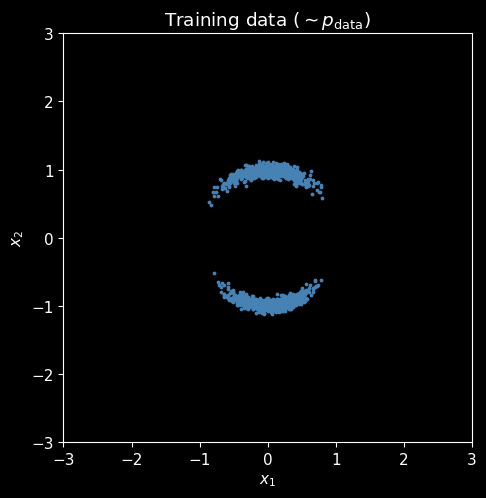

In [3]:
def sample_data(key, n=2000, sigma_z=0.3, sigma_obs=0.05):
    """Sample n points from the circular two-cluster dataset.

    Latent z ~ equal mixture of N(pi/2, sigma_z) and N(3pi/2, sigma_z), wrapped to [0, 2pi].
    Observed x = (cos z, sin z) + N(0, sigma_obs^2 I).

    Returns:
        x: (n, 2) observed positions
        z: (n,) true latent angles in [0, 2pi]
    """
    k1, k2, k3 = random.split(key, 3)
    components = random.bernoulli(k1, p=0.5, shape=(n,))
    centers = jnp.where(components, 3 * jnp.pi / 2, jnp.pi / 2)
    z_raw = centers + sigma_z * random.normal(k2, shape=(n,))
    z = z_raw % (2 * jnp.pi)
    x_clean = jnp.stack([jnp.cos(z), jnp.sin(z)], axis=-1)
    x = x_clean + sigma_obs * random.normal(k3, shape=(n, 2))
    return x, z

key = random.PRNGKey(0)
x_data, _ = sample_data(key, n=n_train, sigma_z=sigma_z, sigma_obs=sigma_obs)
num_samples, num_d = x_data.shape
x_lim = (-3, 3)
y_lim = (-3, 3)
print(f"x shape: {x_data.shape}")

fig, ax = plt.subplots(figsize=(5, 6))
ax.scatter(x_data[:, 0], x_data[:, 1], s=3, c='steelblue')
ax.set_title('Training data ($ \\sim p_{\\text{data}}$)')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(*x_lim)
ax.set_ylim(*y_lim)
ax.set_aspect('equal')
plt.tight_layout()

## Analytical score via `jax.grad`
We can use the analytical score function for the toy data set to test sampling. We know the full form,

$$\tilde p(\mathbf{x}) \;\propto\; \int_0^{2\pi} p(z)\,\mathcal{N}\!\big(\mathbf{x};(\cos z,\sin z),\sigma_\text{obs}^2\mathbf{I}\big)\,dz$$

The normalising constant drops out of $\nabla\log p$, so it suffices to build the **unnormalised** $\tilde p$ by summing the 1D latent $z$ on a fine grid (to approximate the integral). Then the score

$$\mathbf{s}(\mathbf{x}) = \nabla_\mathbf{x}\log p(\mathbf{x})$$

is one line with autograd: `score = jax.grad(log_ptilde)`.

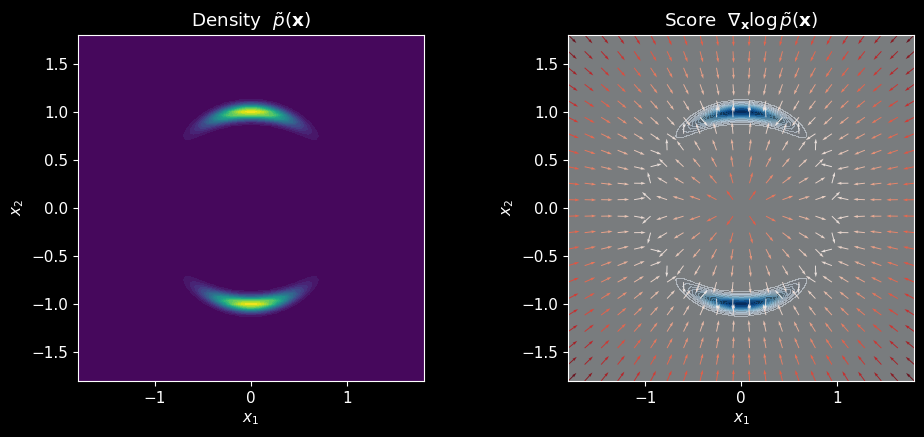

In [4]:
n_z_grid      = 100
z_grid        = jnp.linspace(0.0, 2 * jnp.pi, n_z_grid, endpoint=False)   # (n_z_grid,)
circle_points = jnp.stack([jnp.cos(z_grid), jnp.sin(z_grid)], axis=-1)    # (n_z_grid, 2)

# log p(z): ~ mixture of two wrapped Gaussians at pi/2 and 3pi/2.
log_prior_z = jnp.logaddexp(
    -0.5 * ((z_grid - jnp.pi / 2)     / sigma_z) ** 2,
    -0.5 * ((z_grid - 3 * jnp.pi / 2) / sigma_z) ** 2,
)  # (n_z_grid,)

def log_ptilde(x):
    """Unnormalised log-density at a single 2D point.

    :param x: (2,)  a single 2D point
    :return:  ()    scalar ~ log p_tilde(x), not normalized
    """
    sq_dist_to_circle = jnp.sum((x - circle_points) ** 2, axis=-1)  # sum over coordinates, (n_z_grid,)
    log_likelihood_xz = -0.5 * sq_dist_to_circle / sigma_obs ** 2   # log p(x|z_i), (n_z_grid,)
    log_joint_xz      = log_prior_z + log_likelihood_xz             # log[p(z_i) p(x|z_i)], (n_z_grid,)
    return jax.scipy.special.logsumexp(log_joint_xz)                # <-- sum over z (the integral), ()

score_analytical = jit(grad(log_ptilde))  # (2,) -> (2,)

def square_grid(n, lim):
    """Square meshgrid on [-lim, lim]^2.

    :return: XX, YY of shape (n, n), and flat points of shape (n**2, 2).
    """
    axis     = np.linspace(-lim, lim, n)
    XX, YY   = np.meshgrid(axis, axis)
    flat_pts = jnp.array(np.stack([XX.ravel(), YY.ravel()], axis=1))
    return XX, YY, flat_pts

lim = 1.8  # shared extent so the contour fills the full quiver area

# Fine grid for the density contour.
n_density = 100
XX, YY, density_pts = square_grid(n_density, lim)
density_flat = vmap(lambda x: jnp.exp(log_ptilde(x)))(density_pts)        # (n_density**2,)
density_grid = np.array(density_flat).reshape(n_density, n_density)

# Coarser grid for the score quiver arrows.
n_quiver = 22
XQ, YQ, quiver_pts = square_grid(n_quiver, lim)
score_vecs = vmap(score_analytical)(quiver_pts)                           # (n_quiver**2, 2)
score_x    = np.array(score_vecs[:, 0]).reshape(n_quiver, n_quiver)
score_y    = np.array(score_vecs[:, 1]).reshape(n_quiver, n_quiver)
score_mag  = np.sqrt(score_x ** 2 + score_y ** 2) + 1e-8

# Plot: density (left) + unit-length score arrows coloured by magnitude (right)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].contourf(XX, YY, density_grid, levels=30, cmap='viridis')
axes[0].set_title(r'Density  $\tilde p(\mathbf{x})$')
axes[1].contourf(XX, YY, density_grid, levels=20, cmap='Blues', alpha=0.5)
axes[1].quiver(XQ, YQ,
               score_x / score_mag, score_y / score_mag,   # unit directions
               score_mag,                                   # colour = steepness
               cmap='Reds', scale=30, alpha=0.85)
axes[1].set_title(r'Score  $\nabla_\mathbf{x}\log\tilde p(\mathbf{x})$')
for ax in axes:
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## SGLD sampling with the analytical score

No training yet — this is a sanity check on the sampling algorithm. We start particles at $\mathcal{N}(\mathbf{0},\mathbf{I})$ and apply the SGLD update steps using the analytical score.

The second panel shows the drift-plus-noise dynamics with individual trajectories.

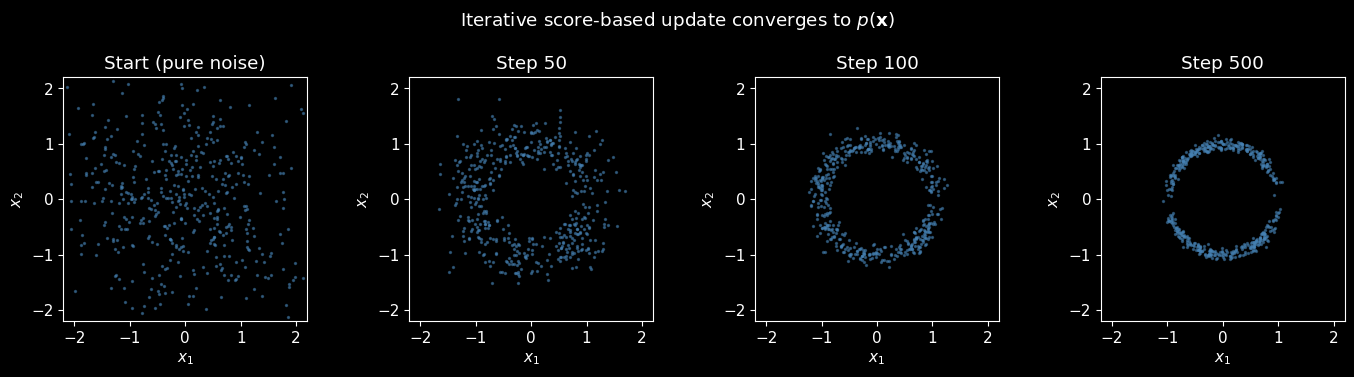

In [5]:
@jit
def langevin_step(x, key, step_size):
    # One step of the discrete iterative update using the analytical score
    s = vmap(score_analytical)(x)       # (N, 2)
    z = random.normal(key, x.shape)     # (N, 2)
    return x + step_size * s + jnp.sqrt(2 * step_size) * z

key, sk = random.split(key)
n_samples = 500
# Score magnitudes are O(1/sigma_obs^2) near the ring (~400 here), so use a
# small step so that step_size * score stays sub-scale compared to sigma_obs.
step_size = 5e-5
n_steps   = 500

x_chain   = random.normal(sk, (n_samples, 2))
snapshots = {0: np.array(x_chain)}

for step in range(n_steps):
    key, sk  = random.split(key)
    x_chain  = langevin_step(x_chain, sk, step_size)
    if step + 1 in (50, 100, 500):
        snapshots[step + 1] = np.array(x_chain)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
titles = ['Start (pure noise)', 'Step 50', 'Step 100', 'Step 500']
for ax, (t, snap), title in zip(axes, snapshots.items(), titles):
    ax.scatter(snap[:, 0], snap[:, 1], s=2, alpha=0.5, c='steelblue')
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2)
    ax.set_title(title); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_aspect('equal')
plt.suptitle(r'Iterative score-based update converges to $p(\mathbf{x})$', y=1.02)
plt.tight_layout(); plt.show()

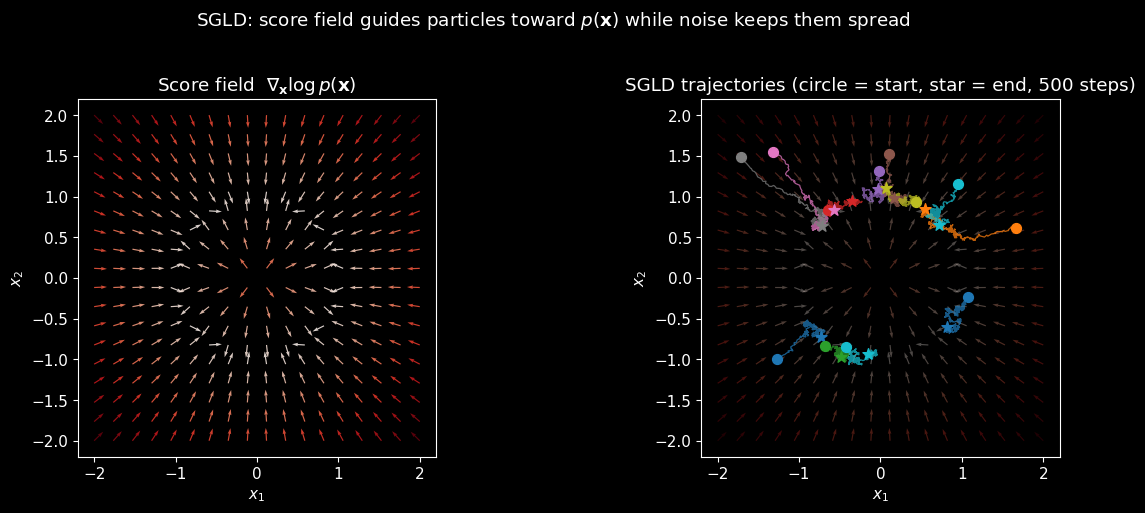

In [6]:
# Visualisation: score field + individual SGLD trajectories

n_grid = 18
xg = np.linspace(-2.0, 2.0, n_grid)
XG, YG = np.meshgrid(xg, xg)
grid_vis = jnp.stack([jnp.array(XG.ravel()), jnp.array(YG.ravel())], axis=1)
S_vis = vmap(score_analytical)(grid_vis)
Sx = np.array(S_vis[:, 0]).reshape(n_grid, n_grid)
Sy = np.array(S_vis[:, 1]).reshape(n_grid, n_grid)
mag = np.sqrt(Sx**2 + Sy**2) + 1e-8

# Short chain for a handful of particles so individual paths are legible
n_traj       = 12
n_traj_steps = 500
key, sk      = random.split(key)
x_traj       = random.uniform(sk, (n_traj, 2), minval=-1.8, maxval=1.8)
traj_hist    = [np.array(x_traj)]

for _ in range(n_traj_steps):
    key, sk = random.split(key)
    s_t     = vmap(score_analytical)(x_traj)
    z_t     = random.normal(sk, x_traj.shape)
    x_traj  = x_traj + step_size * s_t + jnp.sqrt(2 * step_size) * z_t
    traj_hist.append(np.array(x_traj))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: score field only
ax = axes[0]
ax.quiver(XG, YG, Sx/mag, Sy/mag, mag, cmap='Reds', scale=28, alpha=0.85)
ax.set_title('Score field  $\\nabla_{\\mathbf{x}}\\log p(\\mathbf{x})$')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_aspect('equal'); ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2)

# Right: trajectories overlaid on score field
ax = axes[1]
ax.quiver(XG, YG, Sx/mag, Sy/mag, mag, cmap='Reds', scale=28, alpha=0.3)
colors = plt.cm.tab10(np.linspace(0, 1, n_traj))
for i in range(n_traj):
    xs = [traj_hist[k][i, 0] for k in range(n_traj_steps + 1)]
    ys = [traj_hist[k][i, 1] for k in range(n_traj_steps + 1)]
    ax.plot(xs, ys, lw=0.9, alpha=0.75, color=colors[i])
    ax.scatter(xs[0],  ys[0],  s=50, color=colors[i], zorder=5, marker='o')   # start
    ax.scatter(xs[-1], ys[-1], s=70, color=colors[i], zorder=5, marker='*')   # end
ax.set_title(f'SGLD trajectories (circle = start, star = end, {n_traj_steps} steps)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_aspect('equal'); ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2)

plt.suptitle('SGLD: score field guides particles toward $p(\\mathbf{x})$ while noise keeps them spread', y=1.02)
plt.tight_layout(); plt.show()

## Multi-scale learning and annealed sampling (NCSN)

Train one network across geometrically spaced noise levels with the $\sigma^2$-weighted DSM loss. Each training step picks a random $\sigma_i$ per sample.

Noise levels: [0.03  0.043 0.061 0.087 0.124 0.178 0.253 0.362 0.516 0.737 1.051 1.5  ]


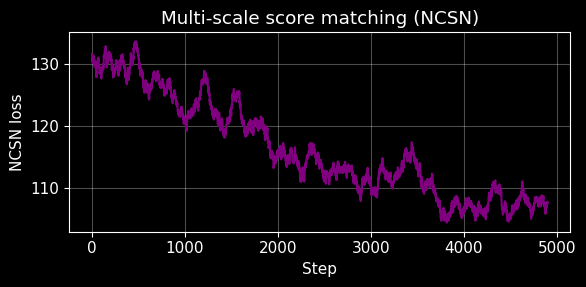

In [7]:
class NoisyScoreNet(nn.Module):
    hidden: int = 128

    @nn.compact
    def __call__(self, x, log_sigma):
        # x: (batch, 2),  log_sigma: (batch,)
        inp = jnp.concatenate([x, log_sigma[:, None]], axis=-1)   # (batch, 3)
        h = nn.Dense(self.hidden)(inp)
        h = nn.tanh(h)
        h = nn.Dense(self.hidden)(h)
        h = nn.tanh(h)
        return nn.Dense(2)(h)

# Geometric sequence: 12 noise levels from sigma=0.03 (below sigma_obs)
# up to sigma=1.5 (large enough to cover the full data extent).
n_sigma = 12
sigma_min, sigma_max = 0.03, 1.5
sigmas = jnp.exp(jnp.linspace(jnp.log(sigma_min), jnp.log(sigma_max), n_sigma))
print('Noise levels:', np.round(np.array(sigmas), 3))

ncsn_net    = NoisyScoreNet()
key, sk     = random.split(key)
params_ncsn = ncsn_net.init(sk, x_data[:4], jnp.zeros(4))
optimizer_ncsn = optax.adam(1e-3)
opt_state_ncsn = optimizer_ncsn.init(params_ncsn)

@jit
def ncsn_loss(params, x_batch, key):
    # NCSN loss: sigma^2-weighted DSM, one randomly chosen sigma per sample
    k1, k2  = random.split(key)
    idx     = random.randint(k1, (x_batch.shape[0],), 0, n_sigma)
    sigma_b = sigmas[idx]                                     # (batch,)
    eps     = random.normal(k2, x_batch.shape)
    x_noisy = x_batch + sigma_b[:, None] * eps
    target  = -eps / sigma_b[:, None]
    log_s   = jnp.log(sigma_b)
    s_pred  = ncsn_net.apply(params, x_noisy, log_s)
    return jnp.mean(sigma_b[:, None]**2 * jnp.sum((s_pred - target)**2, axis=-1))

@jit
def train_step_ncsn(params, opt_state, x_batch, key):
    loss, grads = jax.value_and_grad(ncsn_loss)(params, x_batch, key)
    updates, new_opt = optimizer_ncsn.update(grads, opt_state)
    return optax.apply_updates(params, updates), new_opt, loss

losses_ncsn = []
for step in range(5000):
    key, sk1, sk2 = random.split(key, 3)
    idx = random.choice(sk1, len(x_data), shape=(batch_size,), replace=False)
    params_ncsn, opt_state_ncsn, loss = train_step_ncsn(
        params_ncsn, opt_state_ncsn, x_data[idx], sk2)
    losses_ncsn.append(float(loss))

plt.figure(figsize=(6, 3))
plt.plot(np.convolve(losses_ncsn, np.ones(100)/100, mode='valid'), lw=1.5, c='purple')
plt.xlabel('Step'); plt.ylabel('NCSN loss')
plt.title('Multi-scale score matching (NCSN)'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Annealed Langevin sampling

Start with a large $\sigma$, take many SGLD steps, anneal to a smaller $\sigma$, repeat.

The first visualisation shows the learned score field at four noise levels
- coarse-$\sigma$ field covers the full plane with arrows pointing toward the data (messy in the middle, where density is flat)
- fine-$\sigma$ field is sharp at the ring but near-zero everywhere else

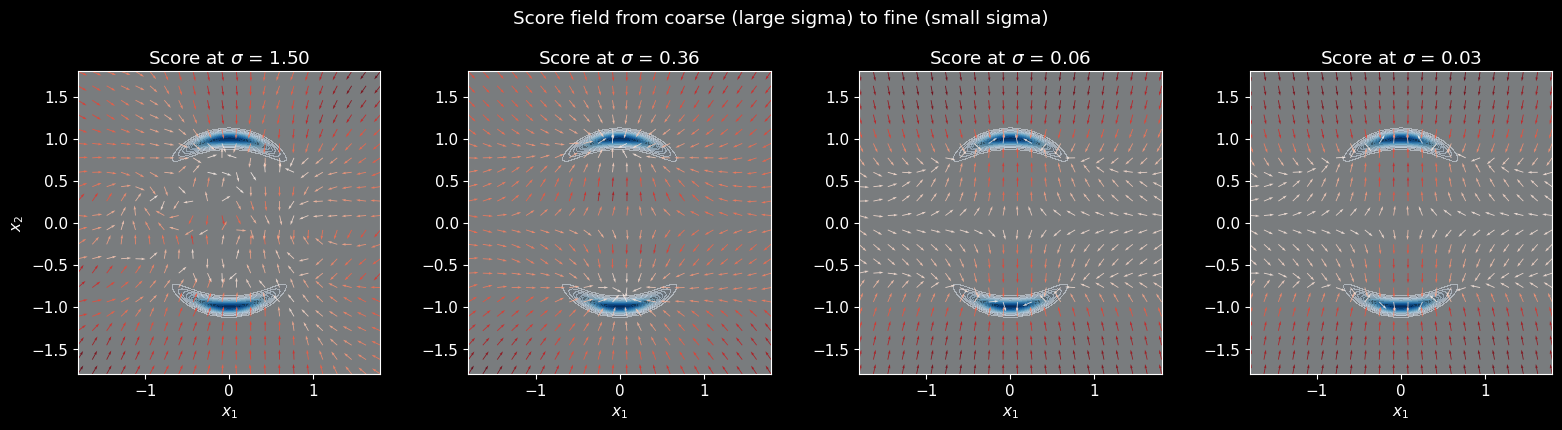

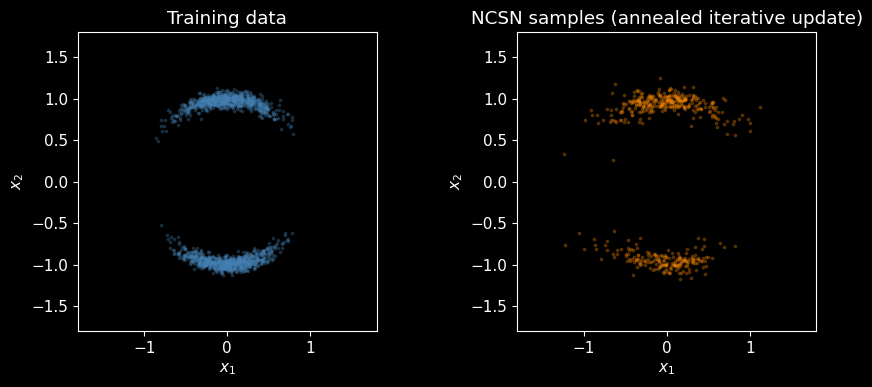

In [8]:
# Score fields at four noise levels: coarse to fine
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, si in zip(axes, [n_sigma-1, n_sigma//2+1, 2, 0]):
    sv = float(sigmas[si])
    s_v = vmap(lambda x: ncsn_net.apply(
        params_ncsn, x[None], jnp.array([jnp.log(sv)]))[0])(quiver_pts)
    sx_ = np.array(s_v[:, 0]).reshape(n_quiver, n_quiver)
    sy_ = np.array(s_v[:, 1]).reshape(n_quiver, n_quiver)
    m_  = np.sqrt(sx_**2 + sy_**2) + 1e-8
    ax.contourf(XX, YY, density_grid, levels=20, cmap='Blues', alpha=0.5)
    ax.quiver(XQ, YQ, sx_/m_, sy_/m_, m_, cmap='Reds', scale=30, alpha=0.85)
    ax.set_title(f'Score at $\\sigma$ = {sv:.2f}')
    ax.set_xlabel('$x_1$'); ax.set_aspect('equal')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
axes[0].set_ylabel('$x_2$')
plt.suptitle('Score field from coarse (large sigma) to fine (small sigma)', y=1.02)
plt.tight_layout(); plt.show()

# Annealed iterative sampling
key, sk  = random.split(key)
N_samp   = 500
alpha    = 0.1   # step size factor: epsilon_i = alpha * sigma_i^2 / sigma_max^2
x_ncsn   = random.normal(sk, (N_samp, 2)) * float(sigma_max)

for sv in reversed(np.array(sigmas)):
    step_size_i = alpha * sv**2 / sigma_max**2
    log_sv      = jnp.log(sv) * jnp.ones(N_samp)
    for _ in range(50):
        key, sk = random.split(key)
        z       = random.normal(sk, x_ncsn.shape)
        s       = ncsn_net.apply(params_ncsn, x_ncsn, log_sv)
        x_ncsn  = x_ncsn + step_size_i * s + jnp.sqrt(2 * step_size_i) * z

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(x_data[:, 0], x_data[:, 1], s=3, alpha=0.25, c='steelblue')
axes[0].set_title('Training data')
axes[1].scatter(np.array(x_ncsn[:, 0]), np.array(x_ncsn[:, 1]),
                s=3, alpha=0.25, c='darkorange')
axes[1].set_title('NCSN samples (annealed iterative update)')
for ax in axes:
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Why annealing matters

Two short SGLD runs with a **single** fixed $\sigma$ each — same 200 steps, same starting grid. Arrows go from start to end.

- **Small $\sigma$**: Some particles barely move — a point in a low-probability valley stays there
- **Large $\sigma$**: Particles wander far and end up spread across the blurred density

Annealing combines the two: large $\sigma$ first redistributes mass across modes, small $\sigma$ sharpens onto the data.

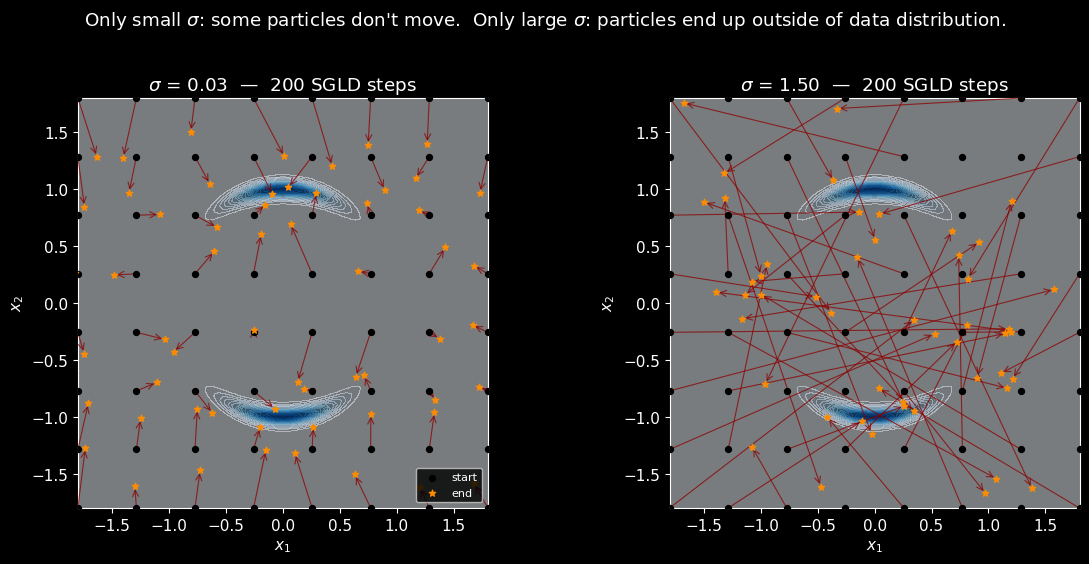

In [9]:
n_side  = 8
starts  = np.stack(np.meshgrid(
    np.linspace(-lim, lim, n_side),
    np.linspace(-lim, lim, n_side)), axis=-1).reshape(-1, 2)
x0_j    = jnp.array(starts)
n_steps_fixed = 200
alpha         = 0.1

def run_fixed_sigma(x, sigma, n_steps, key):
    step_i = alpha * sigma ** 2 / sigma_max ** 2
    log_s  = jnp.log(sigma) * jnp.ones(x.shape[0])
    for _ in range(n_steps):
        key, sk = random.split(key)
        z       = random.normal(sk, x.shape)
        s       = ncsn_net.apply(params_ncsn, x, log_s)
        x       = x + step_i * s + jnp.sqrt(2 * step_i) * z
    return x

key, sk1, sk2 = random.split(key, 3)
ends_small = np.array(run_fixed_sigma(x0_j, float(sigma_min), n_steps_fixed, sk1))
ends_large = np.array(run_fixed_sigma(x0_j, float(sigma_max), n_steps_fixed, sk2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, ends, sv in zip(
        axes,
        [ends_small, ends_large],
        [float(sigma_min), float(sigma_max)]):
    ax.contourf(XX, YY, density_grid, levels=20, cmap='Blues', alpha=0.5)
    for (sx, sy), (ex, ey) in zip(starts, ends):
        ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
                    arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8, alpha=0.75))
    ax.scatter(starts[:, 0], starts[:, 1], s=18, c='black',     zorder=3, label='start')
    ax.scatter(ends[:, 0],   ends[:, 1],   s=22, c='darkorange', zorder=3, marker='*', label='end')
    ax.set_title(f'$\\sigma$ = {sv:.2f}  —  {n_steps_fixed} SGLD steps')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')
axes[0].legend(loc='lower right', fontsize=8)
plt.suptitle('Only small $\\sigma$: some particles don\'t move.  '
             'Only large $\\sigma$: particles end up outside of data distribution.', y=1.02)
plt.tight_layout(); plt.show()

## Notes

| Framework | What is learned | Input → Output | Training objective |
|-----------|----------------|-----------------|-------------------|
| **Denoising SM** (Vincent 2011) | $\mathbf{s}_\theta(\tilde{\mathbf{x}},\sigma) \approx \nabla\log p_\sigma$ | $(\tilde{\mathbf{x}},\sigma) \to$ score | MSE against $-\boldsymbol{\varepsilon}/\sigma$ |
| **NCSN** (Song & Ermon 2019) | same, all $\sigma$ jointly | $(\tilde{\mathbf{x}},\sigma) \to$ score | $\sigma^2$-weighted DSM |

1. **$Z$ never appears** — the normalising constant cancels in $\nabla\log p$.
2. **Sampling is the same discrete update at every noise level** — only the step size changes.

### Extensions to Explore

- **Score SDEs** (Song et al. 2021) — take the number of noise levels $L\to\infty$ to obtain a continuous-time SDE. This unifies NCSN and DDPM as two discretisations of the same process, and opens the door to **ODE samplers** (the probability-flow ODE), which are deterministic and typically 10–50× faster than Langevin sampling.
- **Consistency models** (Song et al. 2023) — distill a trained score model into a one- or few-step sampler.
- **SEDD** (Lou et al. 2024) — discrete-data analogue: replace the score by concrete *ratios* $p(\mathbf{y})/p(\mathbf{x})$ to generate discrete valued sequences.